# Logistic Regression

<div style="padding:10px; 
            color:black;
            margin:10px;
            font-size:150%;
            display:block;
            border-radius:1px;
            border-style: solid;
            border-color:skyblue;
            background-color:#00EFFF;
            overflow:hidden;">
    <center>
        <a id='top'></a>
        <b style="color:black">Table of Contents</b>
    </center>
    <ul>
        <li>
            <a href="#1" style="color:black">1 -  Overview</a>
        </li>
        <li>
            <a href="#2" style="color:black">2 -  Imports</a>
        </li>
        <li>
            <a href="#3" style="color:black">3 - Data Loading and Analysis</a>
        </li>
         <li>
            <a href="#4" style="color:black">4 - Data Preprocessing</a>
        </li>
            <li>
            <a href="#5" style="color:black">5 - Model Implementation </a>
        </li>
        <li>
            <a href="#6" style="color:black">6 - Evaluation</a>
        </li>
    </ul>
</div>


<a id="1"></a>
<h1 style='background:#00EFFF;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: #000000;'>Overview</center></h1>


**Let's get started**    


<a id="2"></a>
<h1 style='background:#00EFFF;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: #000000;'>Imports</center></h1>

# Imports

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pprint
import pickle

<a id="3"></a>
<h1 style='background:#00EFFF;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: #000000;'>Data Loading and Analysis</center></h1>

# Data Loading and Analysis

In [2]:
import os
os.listdir('/kaggle/input')
os.listdir('/kaggle/input/datasets/aaditmunje/breast-cancer')

['breast-cancer.csv']

In [3]:
df = pd.read_csv('/kaggle/input/datasets/aaditmunje/breast-cancer/breast-cancer.csv')
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Just run these graphs directly to understand the data

In [5]:
px.histogram(data_frame=df, x='diagnosis', color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])


In [6]:
px.histogram(data_frame=df,x='area_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [7]:
px.histogram(data_frame=df,x='radius_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [8]:
px.histogram(data_frame=df,x='perimeter_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [9]:
px.histogram(data_frame=df,x='smoothness_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [10]:
px.histogram(data_frame=df,x='texture_mean',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])

In [11]:
px.scatter(data_frame=df,x='symmetry_worst',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])


In [12]:
px.scatter(data_frame=df,x='concavity_worst',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])


In [13]:
px.scatter(data_frame=df,x='fractal_dimension_worst',color='diagnosis',color_discrete_sequence=['#05445E','#75E6DA'])


<a id="4"></a>
<h1 style='background:#00EFFF;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: #000000;'>Data Preprocessing</center></h1>

# Data Preprocessing

In [4]:
print(df.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [5]:
df.drop('id', axis=1, inplace=True, errors='ignore') #drop redundant columns


In [6]:
# encode the 'diagnosis' column in a DataFrame so that malignant ('M') is represented as 1 and all other values as 0

# fill here
df['diagnosis'] = (df['diagnosis'] == 'M').astype(int)

**Now let's get highly correlated features with the target**

In [7]:
corr = df.corr()

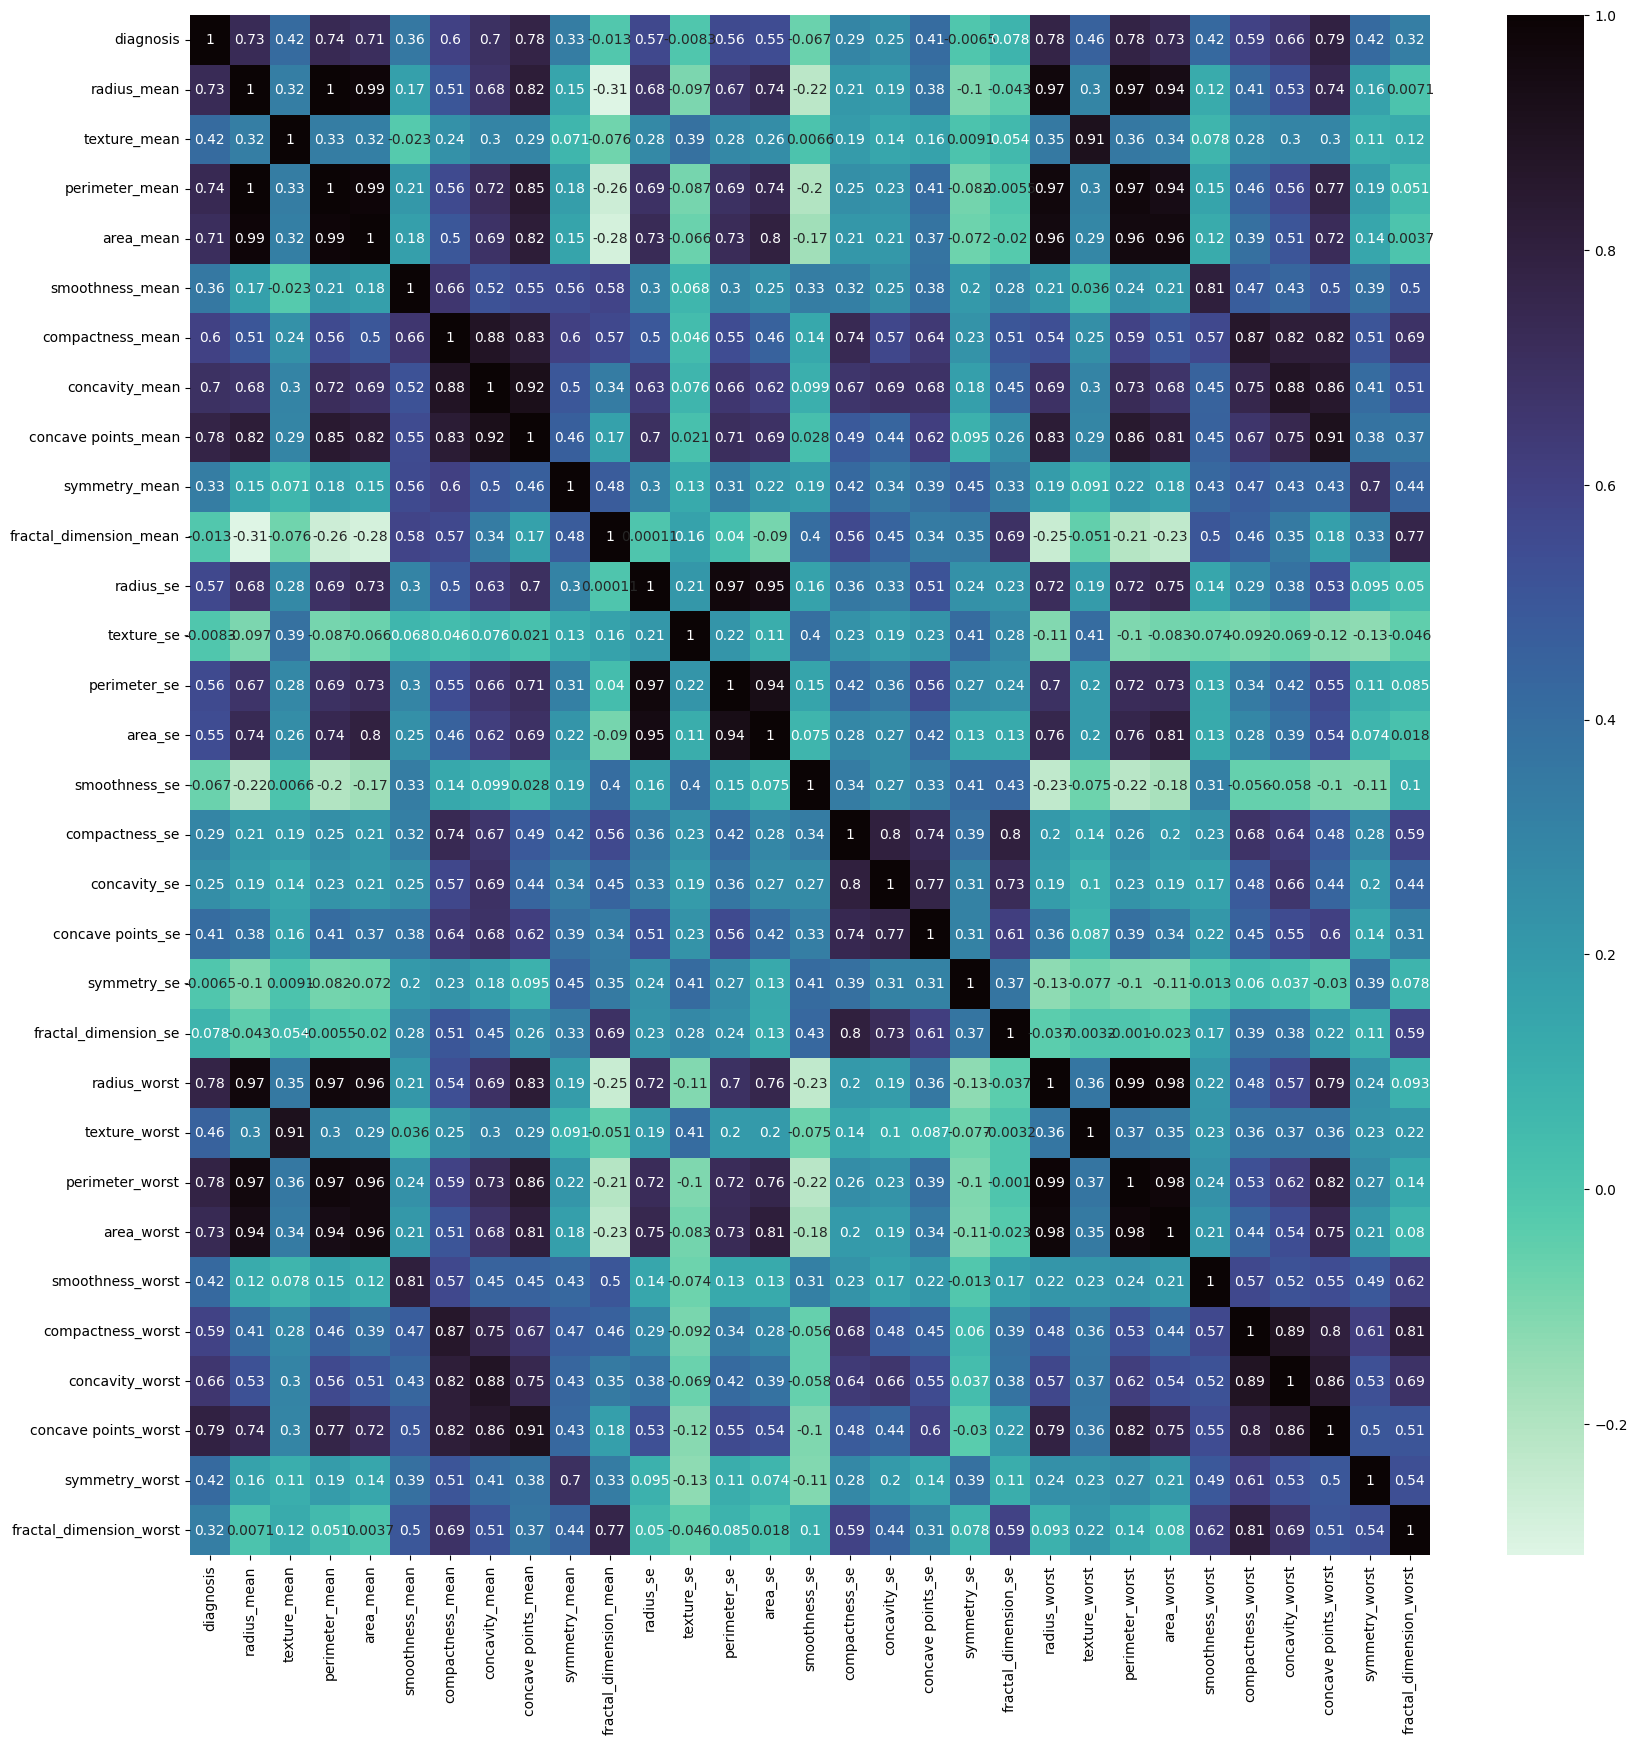

In [8]:
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='mako_r',annot=True)
plt.show()

In [9]:
cor_target = abs(corr['diagnosis'])

relevant_features = cor_target[cor_target > 0.2]

names = list(relevant_features.index)

names = [n for n in names if n != 'diagnosis']

print(names)

['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean', 'concave points_mean', 'symmetry_mean', 'radius_se', 'perimeter_se', 'area_se', 'compactness_se', 'concavity_se', 'concave points_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst', 'symmetry_worst', 'fractal_dimension_worst']


In [10]:
X = df[names].values
y = df['diagnosis'].values

In [12]:
def train_test_split(X, y, random_state=42, test_size=0.2):
    # Get number of samples
    n_samples = X.shape[0]

    # Set the seed for reproducibility
    np.random.seed(random_state)

    # Shuffle the indices
    shuffled_indices = np.random.permutation(n_samples)

    # Determine the size of the test set
    test_size = int(n_samples * test_size)

    # Split the indices into test and train
    test_indices = shuffled_indices[:test_size]
    train_indices = shuffled_indices[test_size:]

    # Split the features and target arrays
    X_train, X_test = X[train_indices], X[test_indices]
    y_train, y_test = y[train_indices], y[test_indices]

    return X_train, X_test, y_train, y_test

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X,y)

## Standardize the data

Standardization is a preprocessing technique used in machine learning to rescale and transform the features (variables) of a dataset to have a mean of 0 and a standard deviation of 1. It is also known as "z-score normalization" or "z-score scaling." Standardization is an essential step in the data preprocessing pipeline for various reasons:

### Why Use Standardization in Machine Learning?

1. **Mean Centering**: Standardization centers the data by subtracting the mean from each feature. This ensures that the transformed data has a mean of 0. Mean centering is crucial because it helps in capturing the relative variations in the data.

2. **Scale Invariance**: Standardization scales the data by dividing each feature by its standard deviation. This makes the data scale-invariant, meaning that the scale of the features no longer affects the performance of many machine learning algorithms. Without standardization, features with larger scales may dominate the learning process.

3. **Improved Convergence**: Many machine learning algorithms, such as gradient-based optimization algorithms (e.g., gradient descent), converge faster when the features are standardized. It reduces the potential for numerical instability and overflow/underflow issues during training.

4. **Comparability**: Standardizing the features makes it easier to compare and interpret the importance of each feature. This is especially important in models like linear regression, where the coefficients represent the feature's impact on the target variable.

5. **Regularization**: In regularization techniques like Ridge and Lasso regression, the regularization strength is applied uniformly to all features. Standardization ensures that the regularization term applies fairly to all features.

### How to Standardize Data

The standardization process involves the following steps:

1. Calculate the mean ($\mu$) and standard deviation ($\sigma$) for each feature in the dataset.
2. For each data point (sample), subtract the mean ($\mu$) of the feature and then divide by the standard deviation ($\sigma$) of the feature.

Mathematically, the standardized value for a feature `x` in a dataset is calculated as:

$$
\text{Standardized value} = \frac{x - \mu}{\sigma}
$$

Here, `x` is the original value of the feature, $\mu$ is the mean of the feature, and $\sigma$ is the standard deviation of the feature.


In [18]:
def standardize_data(X_train, X_test):
    # Calculate mean and std from training data only
    mean = X_train.mean(axis=0)
    std = X_train.std(axis=0)

    # Standardize
    X_train = (X_train - mean) / std
    X_test = (X_test - mean) / std

    return X_train, X_test

X_train, X_test = standardize_data(X_train, X_test)

<a id="5"></a>
<h1 style='background:#00EFFF;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: #000000;'>Model Implementation</center></h1>

# Model Implementation

# Model

# Logistic Regression Model

Logistic regression is a widely used model in machine learning for binary classification tasks. It models the probability that a given input belongs to a particular class. The logistic regression model function is represented as:

$$ f_{\mathbf{w},b}(\mathbf{x}) = g(\mathbf{w} \cdot \mathbf{x} + b) $$

In this equation, $f_{\mathbf{w},b}(\mathbf{x})$ represents the predicted probability, $\mathbf{w}$ is the weight vector, $\mathbf{b}$ is the bias term, $\mathbf{x}$ is the input feature vector, and $g(z)$ is the sigmoid function:

$$ g(z) = \frac{1}{1 + e^{-z}} $$

## Model Training

To train a logistic regression model, we aim to find the best values for the parameters $(\mathbf{w}, b)$ that best fit our dataset and provide accurate class probabilities.

### Forward Pass

The forward pass computes the linear combination of input features $\mathbf{x}$ with the weight vector $\mathbf{w}$ and the bias term $b$ and then applies the sigmoid function to the result:

$$ Z = \mathbf{x} \cdot \mathbf{w} + b $$
$$ A = \sigma(Z) $$

### Cost Function

The cost function measures the error between the predicted probabilities and the true labels. In logistic regression, we use the binary cross-entropy loss function:

$$ J(\mathbf{w},b) = -\frac{1}{m} \sum_{i=0}^{m-1} \left[y_i \log\left(f_{\mathbf{w},b}(\mathbf{x}_i)\right) + (1 - y_i) \log\left(1 - f_{\mathbf{w},b}(\mathbf{x}_i)\right)\right] $$

Here, $m$ is the number of samples, $y_i$ is the true label of sample $i$, and $f_{\mathbf{w},b}(\mathbf{x}_i)$ is the predicted probability of sample $i$ belonging to the positive class.

### Backward Pass (Gradient Computation)

The backward pass calculates the gradients of the cost function with respect to the parameters $(\mathbf{w}, b)$. These gradients are essential for updating the model parameters during training:

$$ \frac{\partial J(\mathbf{w},b)}{\partial b} = \frac{1}{m} \sum_{i=0}^{m-1} \left(f_{\mathbf{w},b}(\mathbf{x}_i) - y_i\right) $$

$$ \frac{\partial J(\mathbf{w},b)}{\partial \mathbf{w}} = \frac{1}{m} \sum_{i=0}^{m-1} \left(f_{\mathbf{w},b}(\mathbf{x}_i) - y_i\right)\mathbf{x}_i $$

## Training Process

The training process involves iteratively updating the weight vector $\mathbf{w}$ and bias term $b$ to minimize the cost function. This is typically done through an optimization algorithm like gradient descent. The update equations for parameters are:

$$ \mathbf{w} \leftarrow \mathbf{w} - \alpha \frac{\partial J}{\partial \mathbf{w}} $$

$$ b \leftarrow b - \alpha \frac{\partial J}{\partial b} $$

Here, $\alpha$ represents the learning rate, which controls the step size during parameter updates.

By iteratively performing the forward pass, computing the cost, performing the backward pass, and updating the parameters, the logistic regression model learns to make better predictions and fit the data.


In [20]:
import numpy as np
def sigmoid(z):
    sigmoid_result = 1/(1+np.exp(-z))
    
    return sigmoid_result

**Visualize the shape of the  Logistic function**

In [21]:
z = np.linspace(-12, 12, 200)

fig = px.line(x=z, y=sigmoid(z),title='Logistic Function',template="plotly_dark")
fig.update_layout(
    title_font_color="#41BEE9", 
    xaxis=dict(color="#41BEE9"), 
    yaxis=dict(color="#41BEE9") 
)
fig.show()

## Implementation of Logistic Regression

In [22]:
# Write the code in missing places

class LogisticRegression:

    def __init__(self, learning_rate=0.0001):
        np.random.seed(1)
        self.learning_rate = learning_rate

    def initialize_parameter(self):
        """
        Initializes the parameters of the model.
        """
        self.W = np.zeros(self.X.shape[1])
        self.b = 0.0


    def forward(self, X):
        """
        Computes forward propagation for given input X.

        Parameters:
            X (numpy.ndarray): Input array.

        Returns:
            numpy.ndarray: Output array.
        """
#         print(X.shape, self.W.shape)
        Z = np.matmul(X, self.W) + self.b
        A = sigmoid(Z)
        return A

    def compute_cost(self, predictions):
        m = self.X.shape[0]  # number of training examples
        # compute the cost
        cost = np.sum((-np.log(predictions + 1e-8) * self.y) + (-np.log(1 - predictions + 1e-8)) * (
                1 - self.y))  # we are adding small value epsilon to avoid log of 0
        cost = cost / m
        return cost

    def compute_gradient(self, predictions):
        # get training shape
        m = self.X.shape[0]

        # compute gradients
        dW = np.dot(self.X.T, (predictions - self.y))
        db = np.sum(predictions - self.y)

        # scale gradients
        self.dW = dW / m
        self.db = db / m

    def fit(self, X, y, iterations, plot_cost=True):
        self.X = X
        self.y = y

        self.initialize_parameter()

        costs = []
        for i in range(iterations):
            # forward propagation
            predictions = self.forward(self.X)

            # compute cost
            cost = self.compute_cost(predictions)
            costs.append(cost)

            # compute gradients
            self.compute_gradient(predictions)

            # update parameters
            self.W = self.W - self.learning_rate * self.dW
            self.b = self.b - self.learning_rate * self.db

            # print cost every 100 iterations
            if i % 10000 == 0:
                print("Cost after iteration {}: {}".format(i, cost))

        if plot_cost:
            fig = px.line(y=costs,title="Cost vs Iteration",template="plotly_dark")
            fig.update_layout(
                title_font_color="#41BEE9", 
                xaxis=dict(color="#41BEE9",title="Iterations"), 
                yaxis=dict(color="#41BEE9",title="cost")
            )
            fig.show()


    def predict(self, X):        
        # Write the code to predict the labels
        probabilities = self.forward(X)
        return (probabilities >= 0.5).astype(int)
    
    def save_model(self, filename=None):
        model_data = {
            'learning_rate': self.learning_rate,
            'W': self.W,
            'b': self.b
        }

        with open(filename, 'wb') as file:
            pickle.dump(model_data, file)

    @classmethod
    def load_model(cls, filename):
        with open(filename, 'rb') as file:
            model_data = pickle.load(file)

        # Create a new instance of the class and initialize it with the loaded parameters
        loaded_model = cls(model_data['learning_rate'])
        loaded_model.W = model_data['W']
        loaded_model.b = model_data['b']

        return loaded_model

In [24]:
lg = LogisticRegression()
lg.fit(X_train, y_train,100000)

Cost after iteration 0: 0.6931471605599454
Cost after iteration 10000: 0.25707783705582465
Cost after iteration 20000: 0.19529178673689734
Cost after iteration 30000: 0.1668582075616386
Cost after iteration 40000: 0.149789395486765
Cost after iteration 50000: 0.13818761340315547
Cost after iteration 60000: 0.12968141212489334
Cost after iteration 70000: 0.12311440399881392
Cost after iteration 80000: 0.11785163708790083
Cost after iteration 90000: 0.11351377138600201


In [26]:
lg.save_model("model.pkl")

<a id="6"></a>
<h1 style='background:#00EFFF;border:0; color:black;
    box-shadow: 10px 10px 5px 0px rgba(0,0,0,0.75);
    transform: rotateX(10deg);
    '><center style='color: #000000;'>Evaluation</center></h1>
    
    
    
# Evaluation



**In classification tasks, it's crucial to evaluate the performance of your model. There are several metrics that can help you understand how well your model is performing. Here are four commonly used classification metrics:**
## 1. Accuracy

**Formula:**
$$
\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}
$$

**Description:**
- **Accuracy** measures the proportion of correctly predicted instances out of all instances in a classification model.
- It is a widely used metric for evaluating classification performance.

**Interpretation:**
- A higher accuracy value indicates a better classification model.
- However, accuracy alone may not provide a complete picture, especially in imbalanced datasets.

## 2. Precision

**Formula:**
$$
\text{Precision} = \frac{\text{True Positives}}{\text{True Positives + False Positives}}
$$

**Description:**
- **Precision** measures the proportion of true positive predictions out of all positive predictions made by the model.
- It is a useful metric when the cost of false positives is high.

**Interpretation:**
- Higher precision means the model makes fewer false positive predictions.

## 3. Recall (Sensitivity)

**Formula:**
$$
\text{Recall (Sensitivity)} = \frac{\text{True Positives}}{\text{True Positives + False Negatives}}
$$

**Description:**
- **Recall**, also known as sensitivity or true positive rate, measures the proportion of true positive predictions out of all actual positive instances in the dataset.
- It is a valuable metric when it's essential to capture all positive instances.

**Interpretation:**
- Higher recall means the model captures more of the actual positive instances.

## 4. F1-Score

**Formula:**
$$
\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision + Recall}}
$$

**Description:**
- The **F1-Score** is the harmonic mean of precision and recall.
- It provides a balance between precision and recall, making it a suitable metric when there is a trade-off between false positives and false negatives.

**Interpretation:**
- A higher F1-Score indicates a model that achieves a balance between precision and recall.



In [29]:
class ClassificationMetrics:
    @staticmethod
    def accuracy(y_true, y_pred):
        """
        Computes the accuracy of a classification model.

        Parameters:
        y_true (numpy array): A numpy array of true labels for each data point.
        y_pred (numpy array): A numpy array of predicted labels for each data point.

        Returns:
        float: The accuracy of the model, expressed as a percentage.
        """
        
        # Write the code based on this
        return np.mean(y_true == y_pred)

    @staticmethod
    def precision(y_true, y_pred):
        """
        Computes the precision of a classification model.

        Parameters:
        y_true (numpy array): A numpy array of true labels for each data point.
        y_pred (numpy array): A numpy array of predicted labels for each data point.

        Returns:
        float: The precision of the model, which measures the proportion of true positive predictions
        out of all positive predictions made by the model.
        """
        
        # Write the code based on this
        true_positives = np.sum((y_pred == 1) & (y_true == 1))
        false_positives = np.sum((y_pred == 1) & (y_true == 0))
        return true_positives / (true_positives + false_positives)

    @staticmethod
    def recall(y_true, y_pred):
        """
        Computes the recall (sensitivity) of a classification model.

        Parameters:
        y_true (numpy array): A numpy array of true labels for each data point.
        y_pred (numpy array): A numpy array of predicted labels for each data point.

        Returns:
        float: The recall of the model, which measures the proportion of true positive predictions
        out of all actual positive instances in the dataset.
        """
        
        # Write the code based on this
        true_positives = np.sum((y_pred == 1) & (y_true == 1))
        false_negatives = np.sum((y_pred == 0) & (y_true == 1))
        return true_positives / (true_positives + false_negatives)

    @staticmethod
    def f1_score(y_true, y_pred):
        """
        Computes the F1-score of a classification model.

        Parameters:
        y_true (numpy array): A numpy array of true labels for each data point.
        y_pred (numpy array): A numpy array of predicted labels for each data point.

        Returns:
        float: The F1-score of the model, which is the harmonic mean of precision and recall.
        """
        
        # Write the code based on this
        p = ClassificationMetrics.precision(y_true, y_pred)
        r = ClassificationMetrics.recall(y_true, y_pred)
        return 2 * (p * r) / (p + r)

In [30]:
model = LogisticRegression.load_model("model.pkl")

In [31]:
y_pred = model.predict(X_test)
accuracy = ClassificationMetrics.accuracy(y_test, y_pred)
precision = ClassificationMetrics.precision(y_test, y_pred)
recall = ClassificationMetrics.recall(y_test, y_pred)
f1_score = ClassificationMetrics.f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")
print(f"F1-Score: {f1_score:.2%}")

Accuracy: 98.23%
Precision: 100.00%
Recall: 95.24%
F1-Score: 97.56%
